# Rebalance Timing Luck — the *same* strategy, a *different* Sharpe 🎰
### How the arbitrary day you rebalance can make one book look like a winner and a loser at once

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Does_rebalance_timing_break_inference%3F: Confirmed](https://img.shields.io/badge/Does_rebalance_timing_break_inference%3F-Confirmed-8b949e?style=flat-square)

Every backtest of a *"monthly"* strategy makes one silent choice nobody thinks about: **which day of the month do you rebalance?** The 1st? The 15th? The last? It is supposed to be a trivial detail. It is not. The *same* rule, rebalanced on a different day, can trace a completely different equity curve — and print a completely different Sharpe ratio.

So we take **one** momentum strategy, run it **21 times** — once for each possible rebalance day — on a return world we *built to have no real edge*, and watch what happens. Then we show the free fix that makes the illusion disappear.

> 📓 **This is the plain-language layer.** Want the persistence rank-correlation, the Newey-West *t* and the maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it, on a deterministic synthetic tape. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from timing_luck import data, strategy as st

PERIOD, LOOKBACK, TOP_FRAC = 21, 126, 0.3
# The whole demo runs on the deterministic, offline seed-836 NULL panel (a cross-section where a
# momentum sort has ZERO genuine edge). Synthetic-only method demo — there is no real-tape cell.
RET, TRUTH = data.synthetic_panel(mom_edge=0.0, seed=836)
print("null panel:", RET.shape[1], "assets x", RET.shape[0], "days,",
      RET.index[0].date(), "->", RET.index[-1].date(),
      "| mom_edge %g (fp %s)" % (TRUTH.mom_edge, data.fingerprint(RET)))


null panel: 30 assets x 2600 days, 2012-01-02 -> 2021-12-17 | mom_edge 0 (fp abbc37b5f962)


## The answer first 🎯

| Question | Answer |
|---|---|
| Does the rebalance *day* change your Sharpe? | **Hugely.** The same book prints **-0.24** on its unluckiest day and **+0.17** on its luckiest — a **0.41-Sharpe** swing on the *identical* strategy. |
| Is that gap real skill? | **No — pure luck.** The lucky day this year is a coin-flip next year (rank correlation ≈ **+0.04**). You cannot forecast it. |
| Can you fix it? | **Yes, for free.** *Tranch* the rebalance across every day at once (overlapping portfolios) and the dispersion collapses to a single curve. |
| Is there any real edge here? | **None.** The tape was built with zero momentum edge; the dispersion is noise dressed up as performance. |

> A smooth, high-Sharpe track record can be an accident of *when* the fund rebalances — not proof of skill.

## 1 · The claim

> *"The same rules-based strategy, rebalanced on a different day of the period, produces materially different returns and Sharpe ratios — a phantom dispersion that is pure luck, not skill."* — Hoffstein et al, *Rebalance Timing Luck*

Two index funds can follow the *identical* methodology, differ only in the month they reconstitute, and drift apart by hundreds of basis points a year. Same idea, same rules — different luck of the calendar.

## 2 · So what?

Because allocators hire and fire strategies on a Sharpe ratio. If an arbitrary rebalance date can swing that number from *fire* to *hire*, the number is nearly meaningless without knowing how the rebalance was scheduled — and a backtester can quietly try a few rebalance days and keep the prettiest. The desk has shown you can fake a Sharpe by **searching** for a lucky rule ([344 Backtest-Overfitting](../../344-backtest-overfitting/)) or by **reshaping** the returns ([590 Sharpe-Hacking](../../590-sharpe-hacking/)); here it gets faked by the calendar.

## 3 · How would we even know?

We need a world where we *know* there is no real edge, so any Sharpe dispersion must be luck. So we **build** one: 30 assets, ~10 years of daily returns, a shared market and pure noise — a cross-sectional **momentum** sort on this tape predicts *nothing*.

Then we run **one** momentum book (buy the 6-month winners, short the losers, rebalance every 21 days) — but we run it once for **each rebalance offset**: starting on day 0, day 1, … day 20 of the cycle. Same rule, same data; only the rebalance day moves. If the 21 Sharpes fan out, that fan is pure timing luck.

## 4 · The teardown — let's actually run it

**The fan of luck.** Here are the 21 Sharpe ratios of the identical strategy, one per rebalance day. Watch them spread out.

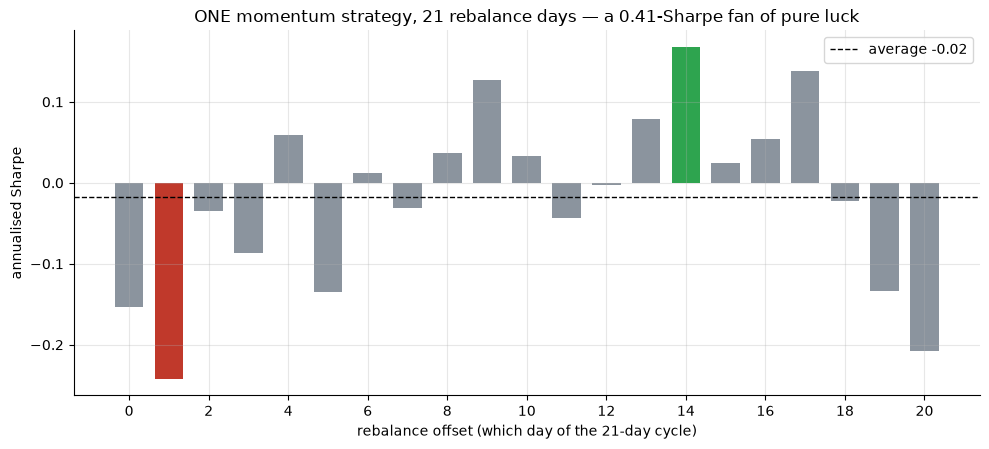

luckiest offset #14: Sharpe +0.168
unluckiest offset #1: Sharpe -0.242
PHANTOM GAP: 0.410 Sharpe units (same rule, same data)


In [2]:
tl = st.timing_luck(RET, PERIOD, LOOKBACK, TOP_FRAC)
sh = tl['sharpes']
fig, ax = plt.subplots(figsize=(10, 4.6))
colors = [GREEN if i == tl['best_offset'] else RED if i == tl['worst_offset'] else GREY for i in range(len(sh))]
ax.bar(np.arange(len(sh)), sh, color=colors, width=.72)
ax.axhline(tl['sharpe_mean'], ls='--', c='k', lw=1, label=f"average {tl['sharpe_mean']:+.2f}")
ax.set_xlabel('rebalance offset (which day of the 21-day cycle)')
ax.set_ylabel('annualised Sharpe'); ax.set_xticks(range(0, 21, 2))
ax.set_title('ONE momentum strategy, 21 rebalance days — a %.2f-Sharpe fan of pure luck' % tl['sharpe_spread'])
ax.legend(); plt.tight_layout(); plt.show()
print('luckiest offset #%d: Sharpe %+.3f' % (tl['best_offset'], tl['sharpe_best']))
print('unluckiest offset #%d: Sharpe %+.3f' % (tl['worst_offset'], tl['sharpe_worst']))
print('PHANTOM GAP: %.3f Sharpe units (same rule, same data)' % tl['sharpe_spread'])

There it is. The **green** bar (offset 14) is a book you'd *keep*; the **red** bar (offset 1) is one you'd *fire* — and they are the **exact same strategy** on the **exact same data**. The only difference is the day of the month the rebalance fell on. That's a **0.41-Sharpe** gap of nothing but luck.

**Is the lucky day *forecastable*?** If it were, the offset that won in the first half of history would tend to win in the second half too. Let's check the ranking's persistence.

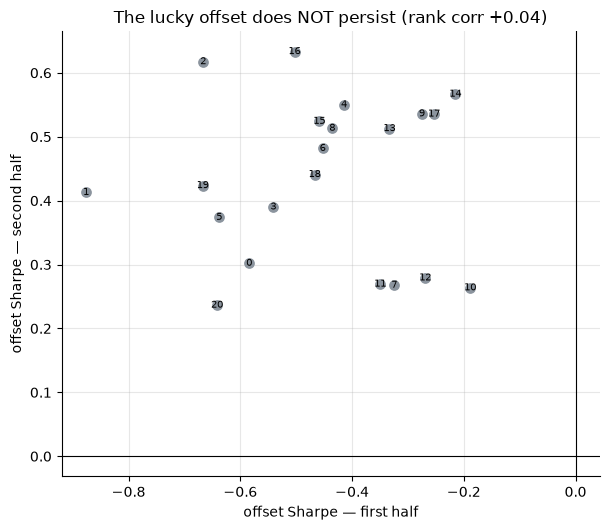

Spearman rank correlation first-half vs second-half: +0.044  (~0 => pure luck)


In [3]:
pr = st.offset_persistence(RET, PERIOD, LOOKBACK, TOP_FRAC)
fig, ax = plt.subplots(figsize=(6.2, 5.4))
ax.scatter(pr['sharpe_h1'], pr['sharpe_h2'], c=GREY, s=45, zorder=3)
for i,(a,b) in enumerate(zip(pr['sharpe_h1'], pr['sharpe_h2'])):
    ax.annotate(str(i), (a,b), fontsize=7, ha='center', va='center')
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('offset Sharpe — first half'); ax.set_ylabel('offset Sharpe — second half')
ax.set_title('The lucky offset does NOT persist (rank corr %+.2f)' % pr['rank_corr'])
plt.tight_layout(); plt.show()
print('Spearman rank correlation first-half vs second-half: %+.3f  (~0 => pure luck)' % pr['rank_corr'])

The cloud is shapeless — the offsets that were lucky early are a coin-flip later (rank correlation **+0.04**). You cannot pick the winning rebalance day in advance, because there is nothing there to pick. **Luck, not skill.**

**The fix — tranching.** Instead of betting the whole book on one arbitrary day, run all 21 offsets at once with 1/21 of the capital each (rebalance a slice every day). Their average is a *single* overlapping portfolio — there is nothing left to be lucky about.

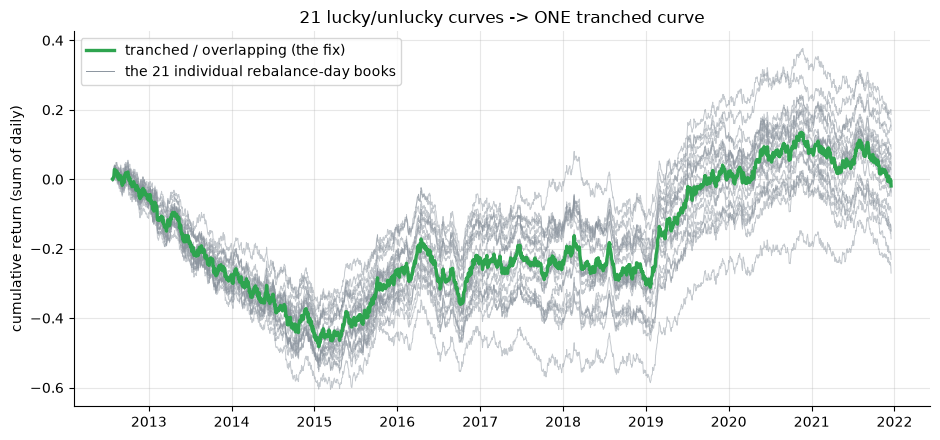

tranched Sharpe -0.019 (NW t = -0.06) — dispersion collapsed to a single curve


In [4]:
tr = st.tranched_portfolio(RET, PERIOD, LOOKBACK, TOP_FRAC)
fig, ax = plt.subplots(figsize=(9.5, 4.5))
start = tr['start']; idx = RET.index[start:]
for off in range(PERIOD):
    port, _ = st.offset_portfolio(RET.to_numpy(), st.trailing_return(RET.to_numpy(), LOOKBACK), off, PERIOD, TOP_FRAC, 6)
    ax.plot(idx, np.cumsum(port[start:]), c=GREY, lw=.7, alpha=.5)
ax.plot(idx, np.cumsum(tr['seg']), c=GREEN, lw=2.4, label='tranched / overlapping (the fix)')
ax.plot([], [], c=GREY, lw=.7, label='the 21 individual rebalance-day books')
ax.set_ylabel('cumulative return (sum of daily)'); ax.set_title('21 lucky/unlucky curves -> ONE tranched curve')
ax.legend(); plt.tight_layout(); plt.show()
print('tranched Sharpe %+.3f (NW t = %+.2f) — dispersion collapsed to a single curve' % (tr['sharpe'], tr['t_nw']))

The grey spaghetti is the 21 timing-luck curves; the **green** line is the single tranched book. The phantom dispersion is **gone** — and on this null tape the tranched Sharpe is **-0.02** (NW *t* = **-0.06**), confirming what we knew: there was never any real edge, just noise the rebalance-day choice was amplifying.

## 5 · The verdict

- **Signal — None.** On a tape with no real edge, the 21 rebalance days fan out by 0.41 Sharpe units of pure luck; the lucky day doesn't persist; the dispersion-free tranched book finds nothing. Nothing real to detect.
- **Tradability — Mirage.** You can't harvest a spread whose winner is a coin-flip, and the tranched null book loses net of costs. Nothing to spend.
- **Does rebalance timing break inference? — Confirmed.** Yes — an arbitrary rebalance date swings the reported Sharpe by ~0.4 units on the identical strategy, and tranching collapses it.

## 6 · Could you actually 'trade' it?

No. To profit from the dispersion you'd have to *know* which rebalance day will be lucky — and it's unforecastable. Picking the best day *in hindsight* is curve-fitting; it won't repeat. The only sane response is the tranched book, which trades every day (so it pays costs) and, on a no-edge tape, earns nothing. There's no free Sharpe to harvest — only a phantom to eliminate.

## 7 · Going further 🚪

- **The other ways to fake a Sharpe.** [344 Backtest-Overfitting](../../344-backtest-overfitting/) fakes it by *searching* many rules; [590 Sharpe-Hacking](../../590-sharpe-hacking/) fakes it by *reshaping* the reported returns. This study fakes it with the *calendar*.
- **The fix is public and free.** Overlapping / tranched portfolios (Blitz–van der Grient–van Vliet 2010) — see the quants notebook for the persistence test and the planted-edge control.

*Think your monthly backtest's Sharpe is robust? Fork this, sweep the rebalance offset on your own strategy, and see how wide the fan is before you trust the headline number.*